# 08. 레짐별 Q 조정 포트폴리오 — Regime-Adaptive BL

## 동기

04_5_GARCH_Evaluation 결과에서 고변동성 레짐에서 GARCH P 분류의 예측력이 떨어지는 현상 확인.

```
저변동성: GARCH IC 0.5631  Baseline IC 0.5122  차이 +0.051  GARCH 우위 73.3%
중간    : GARCH IC 0.5864  Baseline IC 0.5727  차이 +0.014  GARCH 우위 55.0%
고변동성: GARCH IC 0.6130  Baseline IC 0.6191  차이 -0.006  GARCH 우위 45.0%  ← 역전
```

## 해결책: Q를 레짐에 따라 동적으로 조정

P(뷰 행렬)는 GARCH 그대로 유지하되, BL 조정 강도(Q)를 레짐에 따라 다르게 적용.
고변동성에서 Q→0이면 BL이 CAPM으로 수렴하여 P 오분류의 피해를 차단.

| 레짐 | Q 설정 | 근거 |
|------|--------|------|
| 저변동성 | Q_OPTIMAL (0.003) | GARCH 예측력 최고 → 풀 강도 |
| 중간 | Q_OPTIMAL × Q_MID_SCALE | 부분 신뢰 |
| 고변동성 | Q_HIGH_VOL (0.0) | GARCH 우위 소멸 → CAPM 수렴 |

## 파라미터 표

| 파라미터 | 값 | 설명 |
|---------|-----|------|
| `TRAIN_WINDOW` | 60 | 학습 윈도우 (월) |
| `TAU` | 0.1 | BL 스케일 파라미터 |
| `PCT_GROUP` | 0.30 | 저위험/고위험 분류 비율 |
| `Q_OPTIMAL` | 05 자동 로드 | 저변동성 레짐 Q |
| `Q_MID_SCALE` | 0.5 | 중간 레짐 Q 배율 |
| `Q_HIGH_VOL` | 0.0 | 고변동성 레짐 Q |
| 레짐 기준 | SPY 12개월 롤링 변동성 expanding 분위수 | look-ahead 방지 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '08_Regime_Q_Portfolio'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 고정 파라미터 ────────────────────────────────────────────
TRAIN_WINDOW = 60
TAU          = 0.1
PCT_GROUP    = 0.30
START_PRED   = '2011-01-01'

# ── 레짐별 Q 파라미터 ────────────────────────────────────────
Q_MID_SCALE  = 0.5   # 중간 레짐: Q_OPTIMAL × 0.5
Q_HIGH_VOL   = 0.0   # 고변동성 레짐: BL 조정 없이 CAPM 수렴

# ── 최적 Q: 05_Q_Sensitivity 결과에서 자동 로드 ─────────────
STATS_05 = BASE_DIR / 'outputs' / '05_Q_Sensitivity' / 'q_sensitivity_stats.csv'
if STATS_05.exists():
    _s  = pd.read_csv(STATS_05, index_col='label')
    _bl = _s.drop(index=['CAPM', 'SPY'], errors='ignore')
    Q_OPTIMAL = float(_bl['sharpe'].idxmax().split('=')[1])
    print(f'05 결과 자동 로드 → Q_OPTIMAL = {Q_OPTIMAL}')
else:
    Q_OPTIMAL = 0.003
    print(f'05 결과 없음 → 기본값 사용: Q_OPTIMAL = {Q_OPTIMAL}')

Q_LOW_VOL = Q_OPTIMAL                   # 저변동성: 풀 강도
Q_MID_VOL = Q_OPTIMAL * Q_MID_SCALE    # 중간: 절반 강도

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

ret_pivot  = panel['ret_1m'].unstack('ticker')
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

PRED_PATH = DATA_DIR / 'vol_predicted.csv'
assert PRED_PATH.exists(), '04_VolatilityPrediction.ipynb 먼저 실행하세요'
vol_pred_pivot = (pd.read_csv(PRED_PATH, parse_dates=['date'])
                    .set_index(['date', 'ticker'])['vol_pred']
                    .unstack('ticker'))

print(f'패널: {panel.shape}')
print(f'기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'GARCH vol: {vol_pred_pivot.shape}')
print()
print(f'레짐별 Q 설정:')
print(f'  저변동성 → Q = {Q_LOW_VOL:.4f}  (월 {Q_LOW_VOL*100:.2f}%)')
print(f'  중간     → Q = {Q_MID_VOL:.4f}  (월 {Q_MID_VOL*100:.2f}%)')
print(f'  고변동성 → Q = {Q_HIGH_VOL:.4f}  (월 {Q_HIGH_VOL*100:.2f}% — CAPM 수렴)')

05 결과 자동 로드 → Q_OPTIMAL = 0.003
패널: (108135, 11)
기간: 2011-01-31 ~ 2025-12-31 (180개월)
GARCH vol: (180, 610)

레짐별 Q 설정:
  저변동성 → Q = 0.0030  (월 0.30%)
  중간     → Q = 0.0015  (월 0.15%)
  고변동성 → Q = 0.0000  (월 0.00% — CAPM 수렴)


# Black-Litterman 구성 함수

In [2]:
def compute_sigma(ret_matrix):
    lw = LedoitWolf().fit(ret_matrix.values)
    return pd.DataFrame(lw.covariance_,
                        index=ret_matrix.columns,
                        columns=ret_matrix.columns)


def compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt):
    lam = spy_excess / sigma2_mkt if sigma2_mkt > 0 else 2.5
    lam = np.clip(lam, 0.5, 10.0)
    return lam * Sigma @ w_mkt, lam


def build_P(vol_series, mcap_series, pct=0.30):
    n_group  = max(1, int(len(vol_series) * pct))
    idx_sort = vol_series.sort_values().index
    low_risk  = idx_sort[:n_group]
    high_risk = idx_sort[-n_group:]
    P = pd.Series(0.0, index=vol_series.index)
    P[low_risk]  =  mcap_series[low_risk]  / mcap_series[low_risk].sum()
    P[high_risk] = -mcap_series[high_risk] / mcap_series[high_risk].sum()
    return P


def compute_omega(P, Sigma, tau):
    p = P.values
    return max(float(tau * p @ Sigma.values @ p), 1e-8)


def black_litterman(pi, Sigma, P, q, omega, tau):
    p    = P.values
    pi_v = pi.values
    tSig = tau * Sigma.values
    M    = float(p @ tSig @ p) + omega
    diff = q - float(p @ pi_v)
    return pd.Series(pi_v + tSig @ p * (diff / M), index=pi.index)


def optimize_portfolio(mu, Sigma, lam):
    n   = len(mu)
    mu_ = mu.values
    Sig = Sigma.values
    res = minimize(
        fun=lambda w: 0.5 * lam * w @ Sig @ w - w @ mu_,
        x0=np.ones(n) / n,
        jac=lambda w: lam * Sig @ w - mu_,
        method='SLSQP',
        bounds=[(0, 1)] * n,
        constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}],
    )
    if not res.success:
        import warnings
        warnings.warn(f'optimize_portfolio 수렴 실패 → 1/N 대체: {res.message}')
    return pd.Series(res.x if res.success else np.ones(n) / n, index=mu.index)


print('BL 함수 정의 완료')


BL 함수 정의 완료


# 레짐 정의 — SPY 12개월 롤링 변동성

look-ahead bias를 막기 위해 **expanding 분위수**를 사용.
각 시점 t에서 t까지 누적된 rolling vol 분포의 33·67 퍼센타일을 임계값으로 사용.

레짐 분포 (2011~2025):
중간      96
고변동성    60
저변동성    24

Expanding 임계값 (최종 시점):
  q33 = 0.1011  (연환산 변동성 10.1% 이하 → 저변동성)
  q67 = 0.1520  (연환산 변동성 15.2% 이상 → 고변동성)


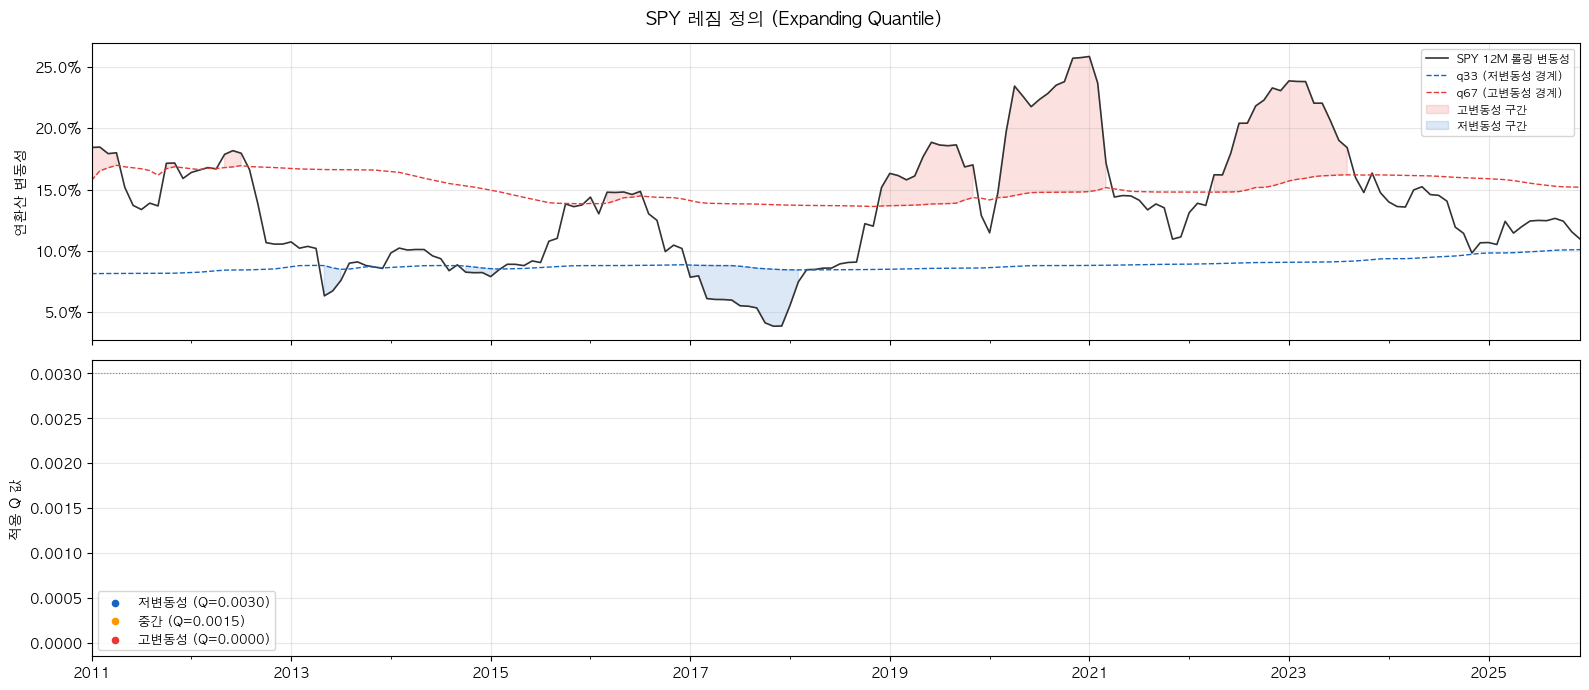

In [3]:
# SPY 12개월 롤링 변동성 (연환산)
spy_roll_vol = spy_series.rolling(12).std() * np.sqrt(12)

# Expanding 분위수 — look-ahead bias 방지
q33_exp = spy_roll_vol.expanding(min_periods=24).quantile(0.33)
q67_exp = spy_roll_vol.expanding(min_periods=24).quantile(0.67)

# 레짐 분류 (pred_dates 구간)
spy_roll_pred = spy_roll_vol.reindex(pred_dates)
q33_pred      = q33_exp.reindex(pred_dates)
q67_pred      = q67_exp.reindex(pred_dates)

regime_series = pd.Series('중간', index=pred_dates)
regime_series[spy_roll_pred <= q33_pred] = '저변동성'
regime_series[spy_roll_pred >= q67_pred] = '고변동성'

print('레짐 분포 (2011~2025):')
print(regime_series.value_counts().to_string())
print()
print('Expanding 임계값 (최종 시점):')
print(f'  q33 = {q33_pred.iloc[-1]:.4f}  (연환산 변동성 {q33_pred.iloc[-1]*100:.1f}% 이하 → 저변동성)')
print(f'  q67 = {q67_pred.iloc[-1]:.4f}  (연환산 변동성 {q67_pred.iloc[-1]*100:.1f}% 이상 → 고변동성)')

# 레짐 시각화
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.suptitle('SPY 레짐 정의 (Expanding Quantile)', fontsize=13, fontweight='bold')

ax = axes[0]
spy_roll_pred.plot(ax=ax, color='#333333', linewidth=1.2, label='SPY 12M 롤링 변동성')
q33_pred.plot(ax=ax, color='#1565C0', linestyle='--', linewidth=1.0, label='q33 (저변동성 경계)')
q67_pred.plot(ax=ax, color='#E53935', linestyle='--', linewidth=1.0, label='q67 (고변동성 경계)')
ax.fill_between(pred_dates,
                spy_roll_pred.where(spy_roll_pred >= q67_pred),
                q67_pred, alpha=0.15, color='#E53935', label='고변동성 구간')
ax.fill_between(pred_dates,
                spy_roll_pred.where(spy_roll_pred <= q33_pred),
                q33_pred, alpha=0.15, color='#1565C0', label='저변동성 구간')
ax.set_ylabel('연환산 변동성')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
q_map = {'저변동성': Q_LOW_VOL, '중간': Q_MID_VOL, '고변동성': Q_HIGH_VOL}
q_regime_ts = regime_series.map(q_map)
color_map   = {'저변동성': '#1565C0', '중간': '#FF9800', '고변동성': '#E53935'}
for reg, color in color_map.items():
    mask = regime_series == reg
    ax.scatter(pred_dates[mask], q_regime_ts[mask], color=color, s=20, label=f'{reg} (Q={q_map[reg]:.4f})', zorder=3)
ax.set_ylabel('적용 Q 값')
ax.set_xlabel('')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(Q_OPTIMAL, color='gray', linestyle=':', linewidth=0.8, label='Q_OPTIMAL')

plt.tight_layout()
plt.savefig(OUT_DIR / 'regime_definition.png', dpi=150, bbox_inches='tight')
plt.show()

# Walk-forward 백테스트

동일한 루프에서 두 전략을 동시에 계산하여 공정하게 비교.
- **Regime-Q**: 레짐에 따라 Q를 동적으로 설정
- **Fixed-Q**: Q = Q_OPTIMAL 항상 고정 (비교 기준)
- **CAPM**: BL 없이 π만으로 최적화
- **SPY**: 시장 지수

In [4]:
regime_records = []   # Regime-Q 전략
fixed_records  = []   # Fixed-Q 비교군
capm_records   = []   # CAPM 벤치마크
spy_records    = []   # SPY 벤치마크
q_log          = []   # 매월 Q 값 기록

print(f'Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')

    try:
        month_base = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_base) < 30:
            continue

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        spy_excess  = (spy_series.reindex(train_dates) - rf_series.reindex(train_dates)).mean()
        sigma2_mkt  = spy_series.reindex(train_dates).var()

        next_date = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        r_spy     = float(spy_series.get(next_date, np.nan)) if next_date else np.nan

        # GARCH vol 적용
        if pred_date not in vol_pred_pivot.index:
            continue
        month_df = month_base.copy()
        month_df['vol_use'] = vol_pred_pivot.loc[pred_date].reindex(month_df.index)
        month_df = month_df.dropna(subset=['vol_use'])
        if len(month_df) < 20:
            continue

        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=month_df.index.tolist())
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        month_df   = month_df.reindex(valid_tix)
        Sigma      = compute_sigma(ret_slice)
        mcap       = np.exp(month_df['log_mcap'])
        w_mkt      = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)
        pi, lam    = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)
        P          = build_P(month_df['vol_use'], mcap, pct=PCT_GROUP)
        P          = P.reindex(valid_tix).fillna(0)
        omega      = compute_omega(P, Sigma, TAU)
        actual_ret = (ret_pivot.loc[next_date].reindex(valid_tix).fillna(0)
                            if next_date is not None
                            else month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0))

        # ── 레짐 판단 ──────────────────────────────────────────
        regime   = regime_series.get(pred_date, '중간')
        q_regime = q_map[regime]

        # ── Regime-Q 전략 ──────────────────────────────────────
        mu_regime = black_litterman(pi, Sigma, P, q_regime, omega, TAU)
        w_regime  = optimize_portfolio(mu_regime, Sigma, lam)
        regime_records.append({'date': pred_date, 'ret': float(w_regime @ actual_ret),
                                'regime': regime, 'q_used': q_regime})

        # ── Fixed-Q 전략 (비교 기준) ──────────────────────────
        mu_fixed = black_litterman(pi, Sigma, P, Q_OPTIMAL, omega, TAU)
        w_fixed  = optimize_portfolio(mu_fixed, Sigma, lam)
        fixed_records.append({'date': pred_date, 'ret': float(w_fixed @ actual_ret)})

        # ── CAPM 벤치마크 ──────────────────────────────────────
        w_capm = optimize_portfolio(pi, Sigma, lam)
        capm_records.append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
        spy_records.append({'date': pred_date, 'ret': r_spy})

        q_log.append({'date': pred_date, 'q_used': q_regime, 'regime': regime})

    except Exception as e:
        if i < 5:
            print(f'  [에러] {pred_date.date()}: {e}')

# DataFrame 변환
regime_df = pd.DataFrame(regime_records).set_index('date')
ret_regime = regime_df['ret']
ret_fixed  = pd.DataFrame(fixed_records).set_index('date')['ret']
ret_capm   = pd.DataFrame(capm_records).set_index('date')['ret']
ret_spy    = pd.DataFrame(spy_records).set_index('date')['ret']
q_df       = pd.DataFrame(q_log).set_index('date')

print(f'\n완료: {len(ret_regime)}개월')
print('레짐별 월수:', q_df['regime'].value_counts().to_dict())


Walk-forward: 2011-01-31 ~ 2025-12-31 (180개월)
  2011-12-31 (12/180)
  2012-12-31 (24/180)
  2013-12-31 (36/180)
  2014-12-31 (48/180)
  2015-12-31 (60/180)
  2016-12-31 (72/180)
  2017-12-31 (84/180)
  2018-12-31 (96/180)
  2019-12-31 (108/180)
  2020-12-31 (120/180)
  2021-12-31 (132/180)
  2022-12-31 (144/180)
  2023-12-31 (156/180)
  2024-12-31 (168/180)
  2025-12-31 (180/180)

완료: 180개월
레짐별 월수: {'중간': 96, '고변동성': 60, '저변동성': 24}


# 성과 분석

In [5]:
ANN        = np.sqrt(12)
rf_monthly = panel['rf_1m'].groupby(level='date').first()

def performance(ret, label):
    rf     = rf_monthly.reindex(ret.index).fillna(0)
    excess = ret - rf
    ann_ret  = ret.mean() * 12
    ann_vol  = ret.std() * ANN
    sharpe   = excess.mean() / excess.std() * ANN
    cum      = (1 + ret).cumprod()
    mdd      = ((cum - cum.cummax()) / cum.cummax()).min()
    cum_ret  = cum.iloc[-1] - 1
    calmar   = ann_ret / abs(mdd) if mdd != 0 else np.nan
    hit_rate = (ret > 0).mean()
    return {
        'label': label,
        '연환산수익률': ann_ret,
        '연환산변동성': ann_vol,
        'Sharpe': sharpe,
        'Calmar': calmar,
        '누적수익률': cum_ret,
        'MDD': mdd,
        '월별승률': hit_rate,
    }

stats_df = pd.DataFrame([
    performance(ret_regime, f'Regime-Q'),
    performance(ret_fixed,  f'Fixed-Q (Q={Q_OPTIMAL})'),
    performance(ret_capm,   'CAPM'),
    performance(ret_spy,    'SPY'),
]).set_index('label')

disp = stats_df.copy()
for col in ['연환산수익률', '연환산변동성', '누적수익률', 'MDD', '월별승률']:
    disp[col] = disp[col].map('{:.2%}'.format)
for col in ['Sharpe', 'Calmar']:
    disp[col] = disp[col].map('{:.3f}'.format)

print('=' * 70)
print(f'성과 비교 ({ret_regime.index[0].date()} ~ {ret_regime.index[-1].date()})')
print('=' * 70)
print(disp.to_string())

regime_sharpe = stats_df.loc['Regime-Q', 'Sharpe']
fixed_sharpe  = stats_df.loc[f'Fixed-Q (Q={Q_OPTIMAL})', 'Sharpe']
capm_sharpe   = stats_df.loc['CAPM', 'Sharpe']
spy_sharpe    = stats_df.loc['SPY',  'Sharpe']

print()
print(f'Regime-Q vs Fixed-Q: Sharpe {regime_sharpe - fixed_sharpe:+.3f}  '
      f'MDD {stats_df.loc["Regime-Q","MDD"] - stats_df.loc[f"Fixed-Q (Q={Q_OPTIMAL})","MDD"]:+.2%}')
print(f'Regime-Q vs CAPM:    Sharpe {regime_sharpe - capm_sharpe:+.3f}')
print(f'Regime-Q vs SPY:     Sharpe {regime_sharpe - spy_sharpe:+.3f}')

# 저장
stats_df.to_csv(OUT_DIR / 'regime_q_stats.csv')
print(f'\n저장: {OUT_DIR}/')

성과 비교 (2011-01-31 ~ 2025-12-31)
                   연환산수익률  연환산변동성 Sharpe Calmar    누적수익률      MDD    월별승률
label                                                                    
Regime-Q           13.59%  12.28%  0.989  0.779  579.18%  -17.45%  68.89%
Fixed-Q (Q=0.003)  13.50%  11.81%  1.019  0.807  575.70%  -16.73%  67.78%
CAPM               14.21%  14.49%  0.882  0.641  612.78%  -22.17%  67.78%
SPY                14.03%  14.06%  0.898  0.586     nan%  -23.93%  68.89%

Regime-Q vs Fixed-Q: Sharpe -0.031  MDD -0.72%
Regime-Q vs CAPM:    Sharpe +0.107
Regime-Q vs SPY:     Sharpe +0.090

저장: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/김윤서/low_risk/outputs/08_Regime_Q_Portfolio/


# 시각화 — 전략 비교

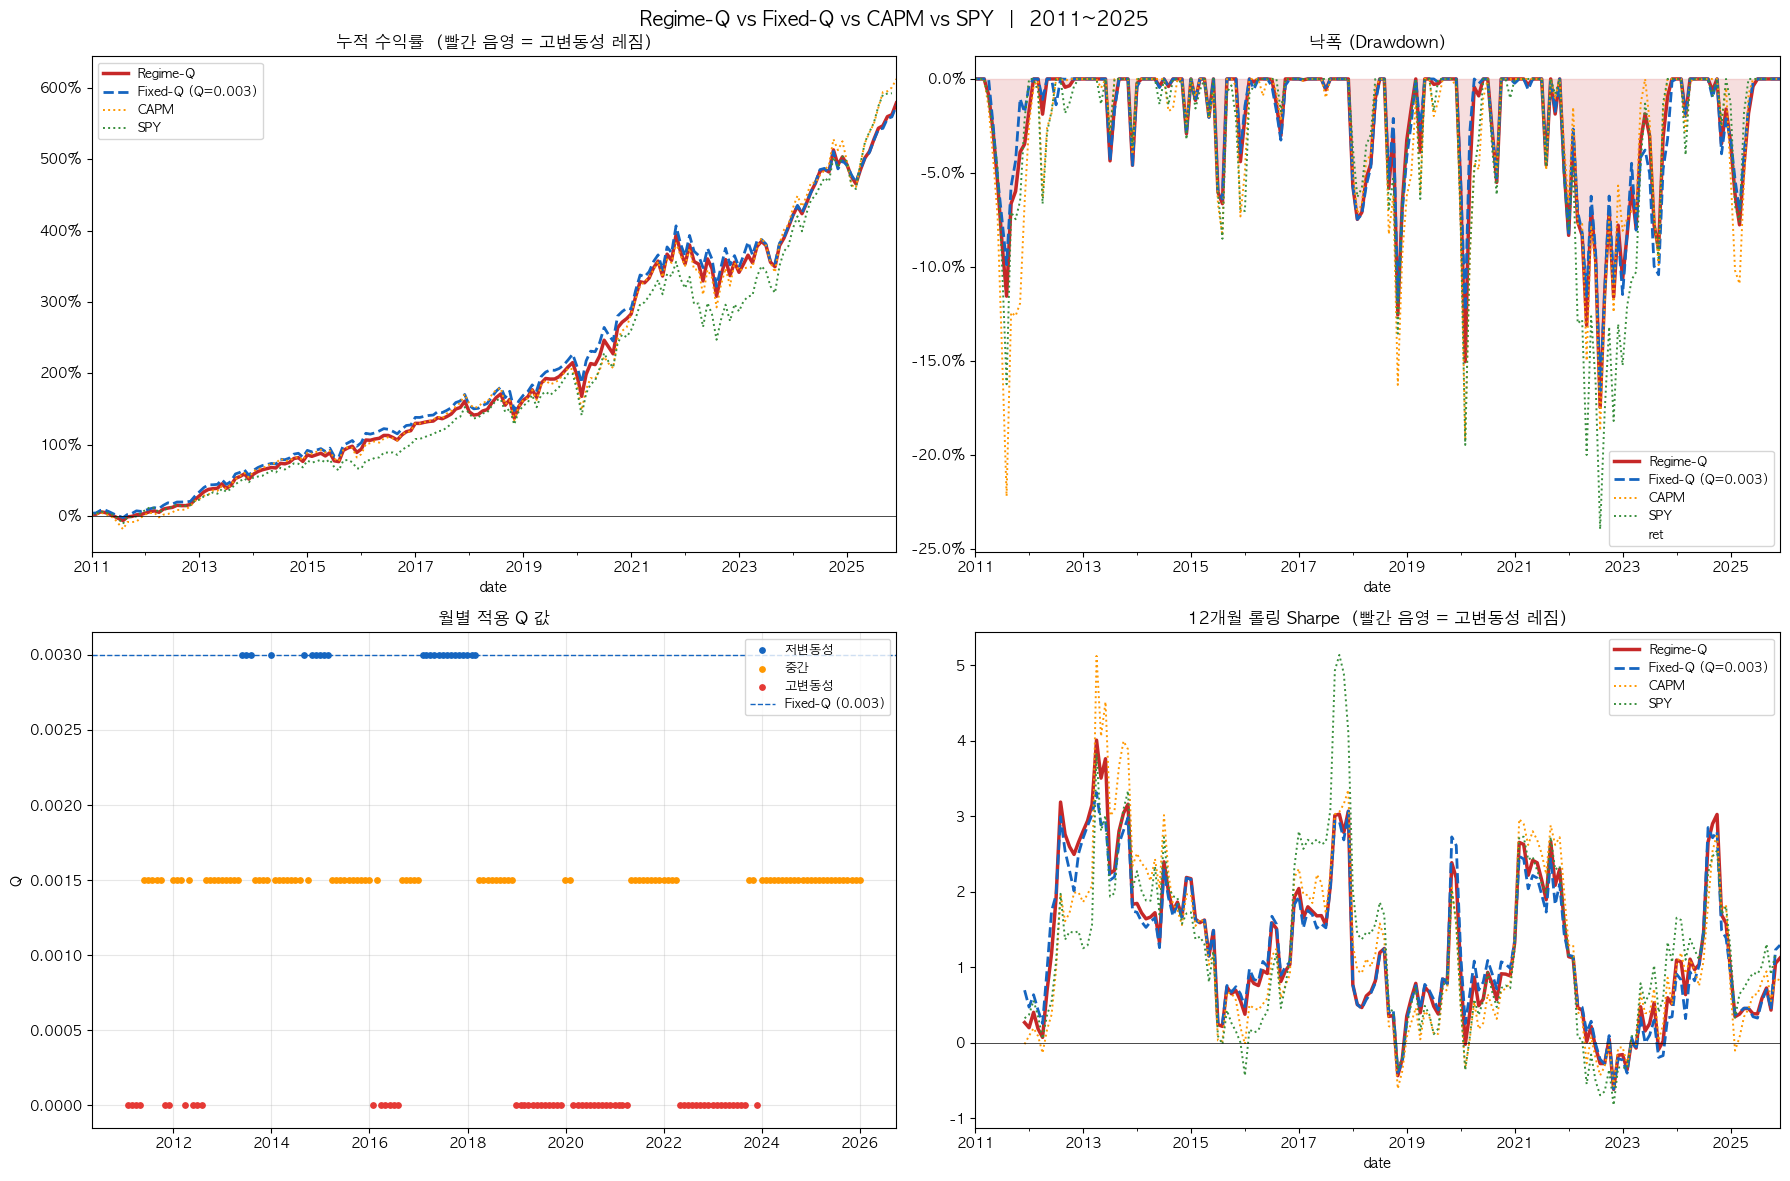

In [6]:
palette = {
    'Regime-Q':          ('#C62828', 2.5, '-'),
    f'Fixed-Q (Q={Q_OPTIMAL})': ('#1565C0', 2.0, '--'),
    'CAPM':              ('#FF9800', 1.4, ':'),
    'SPY':               ('#388E3C', 1.4, ':'),
}
ret_map = {
    'Regime-Q':          ret_regime,
    f'Fixed-Q (Q={Q_OPTIMAL})': ret_fixed,
    'CAPM':              ret_capm,
    'SPY':               ret_spy,
}

# 고변동성 구간 음영 (시각화 보조)
high_vol_mask = q_df['regime'] == '고변동성'
high_vol_dates = q_df.index[high_vol_mask]

def shade_high_vol(ax, dates, color='#FFCDD2', alpha=0.3):
    if len(dates) == 0:
        return
    in_block = False
    start = None
    all_d = list(dates.sort_values())
    for i, d in enumerate(all_d):
        if not in_block:
            start = d
            in_block = True
        if i == len(all_d) - 1 or (all_d[i+1] - d).days > 60:
            ax.axvspan(start, d, alpha=alpha, color=color, linewidth=0)
            in_block = False

def drawdown(ret):
    cum = (1 + ret).cumprod()
    return (cum - cum.cummax()) / cum.cummax()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Regime-Q vs Fixed-Q vs CAPM vs SPY  |  2011~2025', fontsize=14, fontweight='bold')

# ① 누적 수익률
ax = axes[0, 0]
shade_high_vol(ax, high_vol_dates)
for name, (color, lw, ls) in palette.items():
    cum = (1 + ret_map[name]).cumprod() - 1
    cum.plot(ax=ax, label=name, color=color, linewidth=lw, linestyle=ls)
ax.set_title('누적 수익률  (빨간 음영 = 고변동성 레짐)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)

# ② 낙폭
ax = axes[0, 1]
shade_high_vol(ax, high_vol_dates)
for name, (color, lw, ls) in palette.items():
    drawdown(ret_map[name]).plot(ax=ax, label=name, color=color, linewidth=lw, linestyle=ls)
drawdown(ret_regime).plot(ax=ax, color='#C62828', linewidth=0)  # fill용
ax.fill_between(ret_regime.index, drawdown(ret_regime), 0, alpha=0.15, color='#C62828')
ax.set_title('낙폭 (Drawdown)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)

# ③ 레짐별 적용 Q 시계열
ax = axes[1, 0]
for reg, color in color_map.items():
    mask = q_df['regime'] == reg
    ax.scatter(q_df.index[mask], q_df['q_used'][mask],
               color=color, s=15, label=reg, zorder=3)
ax.axhline(Q_OPTIMAL, color='#1565C0', linestyle='--', linewidth=1.0,
           label=f'Fixed-Q ({Q_OPTIMAL})')
ax.set_title('월별 적용 Q 값')
ax.set_ylabel('Q')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ④ 12개월 롤링 Sharpe
ax = axes[1, 1]
shade_high_vol(ax, high_vol_dates)
rf_roll = rf_monthly.reindex(ret_regime.index).fillna(0)

def rolling_sharpe(ret, rf, window=12):
    exc = ret - rf
    return exc.rolling(window).mean() / exc.rolling(window).std() * np.sqrt(12)

for name, (color, lw, ls) in palette.items():
    rf_r = rf_monthly.reindex(ret_map[name].index).fillna(0)
    rolling_sharpe(ret_map[name], rf_r).plot(
        ax=ax, label=name, color=color, linewidth=lw, linestyle=ls)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('12개월 롤링 Sharpe  (빨간 음영 = 고변동성 레짐)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'regime_q_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 레짐별 성과 분해

Regime-Q와 Fixed-Q의 차이가 어느 레짐에서 발생하는지 확인.

In [7]:
print('=' * 65)
print('레짐별 Regime-Q vs Fixed-Q 성과 비교')
print('=' * 65)

regime_by_month = q_df['regime'].reindex(ret_regime.index)

rows = []
for reg in ['저변동성', '중간', '고변동성']:
    mask = regime_by_month == reg
    n = mask.sum()
    if n == 0:
        continue

    r_reg = ret_regime[mask]
    r_fix = ret_fixed[mask]
    rf_sub = rf_monthly.reindex(r_reg.index).fillna(0)

    def sub_stats(ret, rf):
        exc = ret - rf
        sharpe = exc.mean() / exc.std() * ANN if exc.std() > 0 else np.nan
        return ret.mean() * 12, sharpe, (ret > 0).mean()

    ann_r, sh_r, hit_r = sub_stats(r_reg, rf_sub)
    ann_f, sh_f, hit_f = sub_stats(r_fix, rf_sub)

    q_applied = q_map[reg]
    rows.append({
        '레짐': reg,
        '개월수': n,
        '적용Q': q_applied,
        'RegimeQ 연수익': f'{ann_r:.2%}',
        'FixedQ 연수익':  f'{ann_f:.2%}',
        'RegimeQ Sharpe': f'{sh_r:.3f}',
        'FixedQ Sharpe':  f'{sh_f:.3f}',
        'Sharpe 차이':    f'{sh_r - sh_f:+.3f}',
    })

breakdown = pd.DataFrame(rows).set_index('레짐')
print(breakdown.to_string())

print()
print('[해석]')
for _, row in breakdown.iterrows():
    diff = float(row['Sharpe 차이'])
    if diff > 0.02:
        print(f'  {_}: Regime-Q가 Sharpe {diff:+.3f} 우위 (Q={row["적용Q"]} 조정 효과)')
    elif diff < -0.02:
        print(f'  {_}: Fixed-Q가 Sharpe {-diff:.3f} 우위 (Q 조정이 역효과)')
    else:
        print(f'  {_}: 두 전략 성과 유사 (Sharpe 차이 미미)')

레짐별 Regime-Q vs Fixed-Q 성과 비교
      개월수     적용Q RegimeQ 연수익 FixedQ 연수익 RegimeQ Sharpe FixedQ Sharpe Sharpe 차이
레짐                                                                             
저변동성   24  0.0030       5.19%      5.19%          0.461         0.461    +0.000
중간     96  0.0015      12.75%     12.94%          0.973         1.008    -0.035
고변동성   60  0.0000      18.28%     17.72%          1.173         1.212    -0.038

[해석]
  저변동성: 두 전략 성과 유사 (Sharpe 차이 미미)
  중간: Fixed-Q가 Sharpe 0.035 우위 (Q 조정이 역효과)
  고변동성: Fixed-Q가 Sharpe 0.038 우위 (Q 조정이 역효과)


# Q_HIGH_VOL 민감도 분석

고변동성 레짐에서 Q를 0으로 완전히 끄는 것이 최선인지,
아니면 0.001~0.002 수준의 약한 뷰를 유지하는 것이 더 나은지 확인.

민감도 분석 실행 중...

Q_HIGH_VOL 민감도 — 고변동성 레짐 Q 값별 전체 성과
    Q_HIGH       연수익       변동성    Sharpe        MDD
            Q_HIGH=0.0000   13.59%   12.28%     0.989   -17.45%
            Q_HIGH=0.0010   13.53%   12.12%     0.996   -17.19%
            Q_HIGH=0.0015   13.52%   12.05%     1.002   -17.01%
            Q_HIGH=0.0020   13.50%   12.01%     1.003   -17.18%
  Q_HIGH=0.0030 (Fixed-Q)   13.40%   11.93%     1.002   -17.23%

★ Q_HIGH_VOL 최적값: 0.002  (Sharpe 1.003)


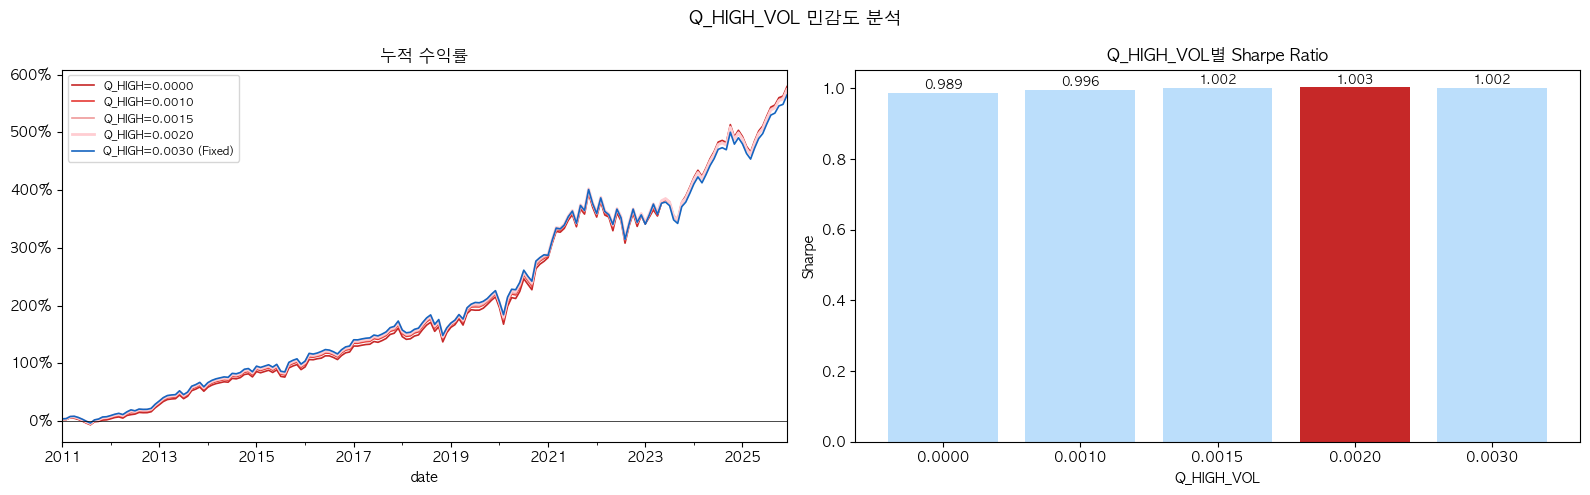

In [8]:
Q_HIGH_CANDIDATES = [0.0, 0.001, 0.0015, 0.002, Q_OPTIMAL]

sens_records = {q: [] for q in Q_HIGH_CANDIDATES}

print('민감도 분석 실행 중...')

for i, pred_date in enumerate(pred_dates):
    try:
        month_base = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_base) < 30:
            continue

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        spy_excess  = (spy_series.reindex(train_dates) - rf_series.reindex(train_dates)).mean()
        sigma2_mkt  = spy_series.reindex(train_dates).var()

        if pred_date not in vol_pred_pivot.index:
            continue
        month_df = month_base.copy()
        month_df['vol_use'] = vol_pred_pivot.loc[pred_date].reindex(month_df.index)
        month_df = month_df.dropna(subset=['vol_use'])
        if len(month_df) < 20:
            continue

        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=month_df.index.tolist())
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        month_df   = month_df.reindex(valid_tix)
        Sigma      = compute_sigma(ret_slice)
        mcap       = np.exp(month_df['log_mcap'])
        w_mkt      = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)
        pi, lam    = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)
        P          = build_P(month_df['vol_use'], mcap, pct=PCT_GROUP)
        P          = P.reindex(valid_tix).fillna(0)
        omega      = compute_omega(P, Sigma, TAU)
        next_date  = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        actual_ret = (ret_pivot.loc[next_date].reindex(valid_tix).fillna(0)
                            if next_date is not None
                            else month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0))

        regime = regime_series.get(pred_date, '중간')

        for q_high in Q_HIGH_CANDIDATES:
            if regime == '고변동성':
                q_use = q_high
            elif regime == '저변동성':
                q_use = Q_OPTIMAL
            else:
                q_use = Q_OPTIMAL * Q_MID_SCALE

            mu_bl = black_litterman(pi, Sigma, P, q_use, omega, TAU)
            w_bl  = optimize_portfolio(mu_bl, Sigma, lam)
            sens_records[q_high].append({'date': pred_date, 'ret': float(w_bl @ actual_ret)})

    except Exception:
        pass

sens_ret = {q: pd.DataFrame(v).set_index('date')['ret'] for q, v in sens_records.items()}

# 성과 요약
print()
print('=' * 60)
print('Q_HIGH_VOL 민감도 — 고변동성 레짐 Q 값별 전체 성과')
print('=' * 60)
print(f'{"Q_HIGH":>10}  {"연수익":>8}  {"변동성":>8}  {"Sharpe":>8}  {"MDD":>9}')

best_sharpe = -np.inf
best_q = None
for q_high in Q_HIGH_CANDIDATES:
    ret = sens_ret[q_high]
    rf  = rf_monthly.reindex(ret.index).fillna(0)
    exc = ret - rf
    ann_ret = ret.mean() * 12
    ann_vol = ret.std() * ANN
    sharpe  = exc.mean() / exc.std() * ANN
    cum = (1 + ret).cumprod()
    mdd = ((cum - cum.cummax()) / cum.cummax()).min()
    label = f'Q_HIGH={q_high:.4f}'
    if q_high == Q_OPTIMAL:
        label += ' (Fixed-Q)'
    star = ' ←' if sharpe > best_sharpe else ''
    if sharpe > best_sharpe:
        best_sharpe = sharpe
        best_q = q_high
    print(f'{label:>25}  {ann_ret:>7.2%}  {ann_vol:>7.2%}  {sharpe:>8.3f}  {mdd:>8.2%}')

print()
print(f'★ Q_HIGH_VOL 최적값: {best_q}  (Sharpe {best_sharpe:.3f})')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Q_HIGH_VOL 민감도 분석', fontsize=13, fontweight='bold')

colors_sens = ['#C62828', '#E53935', '#EF9A9A', '#FFCDD2', '#1565C0']
ax = axes[0]
for (q_high, ret), color in zip(sens_ret.items(), colors_sens):
    label = f'Q_HIGH={q_high:.4f}'
    if q_high == Q_OPTIMAL:
        label += ' (Fixed)'
    ((1 + ret).cumprod() - 1).plot(ax=ax, label=label, color=color,
                                    linewidth=2.0 if q_high == best_q else 1.2)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)
ax.axhline(0, color='black', linewidth=0.5)

ax = axes[1]
q_labels = [f'{q:.4f}' for q in Q_HIGH_CANDIDATES]
sharpes_s = []
for q_high in Q_HIGH_CANDIDATES:
    ret = sens_ret[q_high]
    rf  = rf_monthly.reindex(ret.index).fillna(0)
    exc = ret - rf
    sharpes_s.append(exc.mean() / exc.std() * ANN)
bar_colors = ['#C62828' if q == best_q else '#BBDEFB' for q in Q_HIGH_CANDIDATES]
bars = ax.bar(q_labels, sharpes_s, color=bar_colors)
for bar, val in zip(bars, sharpes_s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Q_HIGH_VOL별 Sharpe Ratio')
ax.set_xlabel('Q_HIGH_VOL')
ax.set_ylabel('Sharpe')

plt.tight_layout()
plt.savefig(OUT_DIR / 'q_high_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


# 결과 저장 및 요약

In [9]:
# 결과 저장
regime_df.to_csv(OUT_DIR / 'regime_q_returns.csv')
ret_fixed.to_csv(OUT_DIR / 'fixed_q_returns.csv', header=['ret'])
q_df.to_csv(OUT_DIR / 'regime_log.csv')
breakdown.to_csv(OUT_DIR / 'regime_breakdown.csv')

print('저장 파일:')
for f in sorted(OUT_DIR.glob('*')):
    print(f'  {f.name}')

print()
print('=' * 60)
print('최종 요약')
print('=' * 60)
print(f'  Regime-Q  Sharpe: {stats_df.loc["Regime-Q", "Sharpe"]:.3f}')
print(f'  Fixed-Q   Sharpe: {stats_df.loc[f"Fixed-Q (Q={Q_OPTIMAL})", "Sharpe"]:.3f}')
print(f'  CAPM      Sharpe: {stats_df.loc["CAPM", "Sharpe"]:.3f}')
print(f'  SPY       Sharpe: {stats_df.loc["SPY", "Sharpe"]:.3f}')
print()
print(f'  Regime-Q vs Fixed-Q: {stats_df.loc["Regime-Q","Sharpe"] - stats_df.loc[f"Fixed-Q (Q={Q_OPTIMAL})","Sharpe"]:+.3f}')
print(f'  최적 Q_HIGH_VOL: {best_q}  (민감도 분석 기준)')

저장 파일:
  fixed_q_returns.csv
  q_high_sensitivity.png
  regime_breakdown.csv
  regime_definition.png
  regime_log.csv
  regime_q_comparison.png
  regime_q_returns.csv
  regime_q_stats.csv

최종 요약
  Regime-Q  Sharpe: 0.989
  Fixed-Q   Sharpe: 1.019
  CAPM      Sharpe: 0.882
  SPY       Sharpe: 0.898

  Regime-Q vs Fixed-Q: -0.031
  최적 Q_HIGH_VOL: 0.002  (민감도 분석 기준)
